# 09 — Context Builder Evaluation

Cette étape transforme les résultats L6+RRF en paquets de sources prêts pour la génération. Elle compare plusieurs nombres de seeds, budgets de tokens et politiques de déduplication/expansion. Le builder ne reçoit jamais les réponses ni les spans gold : ceux-ci interviennent uniquement après la construction pour l'évaluation.

**Contrat expérimental :** validation `direct_user_response` uniquement, test verrouillé, artefacts versionnés, sélection multi-objectifs fondée sur la couverture des preuves et le volume de contexte.

## 1. Dépendances et chemins

Le tokenizer `cl100k_base` mesure le contexte réellement rendu, y compris titres, identifiants de citation et séparateurs. Aucun appel OpenAI et aucune inférence GPU ne sont nécessaires.

In [1]:
%pip install -q "tiktoken>=0.7,<1" numpy pandas matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from __future__ import annotations

import hashlib
import json
import math
import os
import re
import tempfile
import time
from collections import defaultdict
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Iterable, Iterator

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tiktoken
from IPython.display import display

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_colwidth", 180)

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
DATASET_ROOT = PROJECT_ROOT / "data" / "processed" / "multidoc2dial_v1"
CONFIG_PATH = PROJECT_ROOT / "configs" / "context_builder_experiments.json"

print(f"Project root : {PROJECT_ROOT}")
print(f"Configuration : {CONFIG_PATH}")

Project root : C:\Users\dhiar\OneDrive\Bureau\Project\RAG Assistant
Configuration : C:\Users\dhiar\OneDrive\Bureau\Project\RAG Assistant\configs\context_builder_experiments.json


In [3]:
def load_json(path: Path) -> dict[str, Any]:
    value = json.loads(path.read_text(encoding="utf-8"))
    if not isinstance(value, dict):
        raise TypeError(f"La racine de {path} doit être un objet JSON")
    return value


def iter_jsonl(path: Path) -> Iterator[dict[str, Any]]:
    with path.open(encoding="utf-8") as handle:
        for line_number, line in enumerate(handle, 1):
            try:
                yield json.loads(line)
            except json.JSONDecodeError as error:
                raise ValueError(f"JSONL invalide : {path}, ligne {line_number}") from error


def file_sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        while block := handle.read(1024 * 1024):
            digest.update(block)
    return digest.hexdigest()


def stable_hash(value: Any) -> str:
    payload = json.dumps(value, ensure_ascii=False, sort_keys=True, separators=(",", ":"))
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()


def write_json_atomic(path: Path, value: Any) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with tempfile.NamedTemporaryFile("w", encoding="utf-8", delete=False, dir=path.parent, suffix=".tmp") as handle:
        json.dump(value, handle, ensure_ascii=False, indent=2)
        handle.write("\n")
        temporary = Path(handle.name)
    os.replace(temporary, path)


def write_jsonl_atomic(path: Path, records: Iterable[dict[str, Any]]) -> int:
    path.parent.mkdir(parents=True, exist_ok=True)
    count = 0
    with tempfile.NamedTemporaryFile("w", encoding="utf-8", delete=False, dir=path.parent, suffix=".tmp") as handle:
        for record in records:
            handle.write(json.dumps(record, ensure_ascii=False, separators=(",", ":")) + "\n")
            count += 1
        temporary = Path(handle.name)
    os.replace(temporary, path)
    return count


def artifact_metadata(path: Path, records: int | None = None) -> dict[str, Any]:
    result = {
        "path": str(path.relative_to(PROJECT_ROOT)),
        "bytes": path.stat().st_size,
        "sha256": file_sha256(path),
    }
    if records is not None:
        result["records"] = records
    return result


def dataframe_records(frame: pd.DataFrame) -> list[dict[str, Any]]:
    return json.loads(frame.to_json(orient="records", double_precision=12))

## 2. Chargement des contrats d'entrée

Le notebook vérifie les hashes du benchmark, des chunks et des classements L6. Seul `validation.jsonl` est ouvert ; aucun fichier du test n'est lu.

In [4]:
config = load_json(CONFIG_PATH)
config_hash = stable_hash(config)
assert config["evaluation_split"] == "validation"
assert "test" in config["locked_splits"]

reranker_report_path = PROJECT_ROOT / "reports" / "generated" / "multidoc2dial_v1" / "reranking_experiments" / config["reranking_experiment_id"] / "reranking_report.json"
reranker_report = load_json(reranker_report_path)
assert reranker_report["quality"]["status"] == "passed"
assert reranker_report["quality"]["test_split_loaded"] is False
assert reranker_report["selected_mode"] == "CrossEncoderRRF"
assert reranker_report["model"]["model_id"] == "cross-encoder/ms-marco-MiniLM-L6-v2"

ranking_meta = reranker_report["artifacts"]["selected_rankings"]
ranking_path = PROJECT_ROOT / ranking_meta["path"]
assert file_sha256(ranking_path) == ranking_meta["sha256"]
ranking_records = list(iter_jsonl(ranking_path))

benchmark_root = DATASET_ROOT / "retrieval_benchmarks" / config["benchmark_id"]
benchmark_manifest_path = benchmark_root / "manifest.json"
benchmark_manifest = load_json(benchmark_manifest_path)
validation_path = benchmark_root / "validation.jsonl"
validation_expected = benchmark_manifest["outputs"]["validation.jsonl"]
assert file_sha256(validation_path) == validation_expected["sha256"]
validation_examples = [item for item in iter_jsonl(validation_path) if item["cohort"] == config["cohort"]]
assert all(item["split"] == "validation" for item in validation_examples)

chunk_root = DATASET_ROOT / "chunking_experiments" / config["chunking_experiment_id"] / config["chunking_strategy"]
chunk_manifest_path = chunk_root / "manifest.json"
chunk_manifest = load_json(chunk_manifest_path)
chunk_path = chunk_root / "chunks.jsonl"
assert chunk_manifest["quality"]["status"] == "passed"
assert file_sha256(chunk_path) == chunk_manifest["outputs"]["chunks.jsonl"]["sha256"]
chunks = list(iter_jsonl(chunk_path))
chunks_by_id = {item["id"]: item for item in chunks}

query_experiment_id = reranker_report["inputs"]["query_rewriting_experiment_id"]
query_root = DATASET_ROOT / "query_rewriting_experiments" / query_experiment_id
query_manifest = load_json(query_root / "manifest.json")
rewrite_path = query_root / "rewrites" / "validation_rewrites.jsonl"
assert file_sha256(rewrite_path) == query_manifest["artifacts"]["rewrites"]["sha256"]
rewrite_records = list(iter_jsonl(rewrite_path))

example_ids = [item["id"] for item in validation_examples]
examples_by_id = {item["id"]: item for item in validation_examples}
rankings_by_id = {item["example_id"]: item for item in ranking_records}
rewrites_by_id = {item["example_id"]: item for item in rewrite_records}
assert len(example_ids) == len(set(example_ids)) == len(rankings_by_id) == len(rewrites_by_id)
assert set(example_ids) == set(rankings_by_id) == set(rewrites_by_id)
assert all(len(rankings_by_id[key]["candidates"]) >= config["candidate_depth"] for key in example_ids)
assert all(candidate["chunk_id"] in chunks_by_id for key in example_ids for candidate in rankings_by_id[key]["candidates"][: config["candidate_depth"]])

experiment_fingerprint = stable_hash({
    "config": config,
    "reranker_report": file_sha256(reranker_report_path),
    "rankings": ranking_meta["sha256"],
    "benchmark_manifest": file_sha256(benchmark_manifest_path),
    "validation": validation_expected["sha256"],
    "chunks": file_sha256(chunk_path),
    "rewrites": file_sha256(rewrite_path),
})
experiment_id = f"{config['experiment_name']}_{experiment_fingerprint[:10]}"
OUTPUT_ROOT = DATASET_ROOT / "context_builder_experiments" / experiment_id
REPORT_ROOT = PROJECT_ROOT / "reports" / "generated" / "multidoc2dial_v1" / "context_builder_experiments" / experiment_id

print(f"Validation primaire : {len(validation_examples):,}")
print(f"Chunks disponibles : {len(chunks):,}")
print(f"Classement source : {config['reranking_experiment_id']}")
print(f"Test chargé : {False}")
print(f"Experiment ID : {experiment_id}")

Validation primaire : 4,427
Chunks disponibles : 1,273
Classement source : cross_encoder_reranking_l6_v1_2e66c8170f
Test chargé : False
Experiment ID : context_builder_v1_860d7c5b2f


## 3. Représentation exacte du contexte

Chaque source reçoit un identifiant stable dans la réponse (`S1`, `S2`, …). Le coût inclut le titre, le domaine, le `chunk_id`, le texte et les séparateurs. Les voisins sont indexés par `(document_id, position)` mais ne seront ajoutés que dans les politiques qui l'autorisent.

In [5]:
encoding = tiktoken.get_encoding(config["tokenizer"]["encoding"])
rendering = config["rendering"]
policy_grid = config["policy_grid"]


def citation_id(position: int) -> str:
    return f"{rendering['citation_prefix']}{position}"


def render_source(chunk: dict[str, Any], position: int) -> str:
    return rendering["source_template"].format(
        citation_id=citation_id(position),
        domain=chunk["domain"],
        document_title=chunk["document_title"],
        chunk_id=chunk["id"],
        content=chunk["content"],
    )


def render_context(source_ids: list[str]) -> str:
    return rendering["separator"].join(render_source(chunks_by_id[chunk_id], position) for position, chunk_id in enumerate(source_ids, 1))


max_context_chunks = policy_grid["maximum_context_chunks"]
source_token_cost = {
    (chunk_id, position): len(encoding.encode(render_source(chunk, position)))
    for chunk_id, chunk in chunks_by_id.items()
    for position in range(1, max_context_chunks + 1)
}
separator_token_cost = len(encoding.encode(rendering["separator"]))

chunks_by_document_position: dict[str, dict[int, str]] = defaultdict(dict)
for chunk in chunks:
    position_map = chunks_by_document_position[chunk["document_id"]]
    assert chunk["position"] not in position_map
    position_map[chunk["position"]] = chunk["id"]

word_pattern = re.compile(r"[a-z0-9]+")
lexical_sets = {
    chunk_id: frozenset(word_pattern.findall(chunk["content"].casefold()))
    for chunk_id, chunk in chunks_by_id.items()
}


def jaccard(left: frozenset[str], right: frozenset[str]) -> float:
    union = left | right
    return len(left & right) / len(union) if union else 1.0


source_cost_values = [source_token_cost[(chunk_id, 1)] for chunk_id in chunks_by_id]
print(pd.Series(source_cost_values).describe(percentiles=[0.5, 0.95, 0.99]).round(2))
print(f"Séparateur : {separator_token_cost} tokens")

count    1273.00
mean      536.08
std       130.79
min       142.00
50%       594.00
95%       646.00
99%       701.56
max       769.00
dtype: float64
Séparateur : 2 tokens


## 4. Builder indépendant des annotations gold

`build_context` reçoit uniquement un classement et une politique. Il ne reçoit ni l'exemple benchmark, ni les spans, ni la réponse de référence. La déduplication exacte utilise le hash du contenu ; la déduplication proche utilise la similarité de Jaccard entre ensembles de mots. L'expansion ajoute seulement les voisins immédiats des seeds réellement retenus.

In [6]:
def policy_id(mode: str, seed_top_k: int, token_budget: int) -> str:
    return f"{mode}__k{seed_top_k}__b{token_budget}"


def build_context(candidates: list[dict[str, Any]], policy: dict[str, Any], render_final: bool = True) -> dict[str, Any]:
    selected: list[dict[str, Any]] = []
    seen_chunk_ids: set[str] = set()
    seen_content_hashes: set[str] = set()
    used_tokens = 0
    audit = {
        "exact_duplicates_removed": 0,
        "near_duplicates_removed": 0,
        "budget_misses": 0,
        "maximum_chunk_limit_hits": 0,
        "neighbors_added": 0,
    }

    near_dedupe = policy["mode"] == "ranked_near_dedupe"
    add_neighbors = policy["mode"] == "ranked_exact_dedupe_with_neighbors"
    threshold = policy_grid["near_duplicate_jaccard_threshold"]

    def try_add(chunk_id: str, origin: str, source_rank: int | None) -> bool:
        nonlocal used_tokens
        if len(selected) >= max_context_chunks:
            audit["maximum_chunk_limit_hits"] += 1
            return False
        chunk = chunks_by_id[chunk_id]
        if chunk_id in seen_chunk_ids or chunk["content_hash"] in seen_content_hashes:
            audit["exact_duplicates_removed"] += 1
            return False
        if near_dedupe and any(jaccard(lexical_sets[chunk_id], lexical_sets[item["chunk_id"]]) >= threshold for item in selected):
            audit["near_duplicates_removed"] += 1
            return False

        position = len(selected) + 1
        incremental_cost = source_token_cost[(chunk_id, position)] + (separator_token_cost if selected else 0)
        if used_tokens + incremental_cost > policy["token_budget"]:
            audit["budget_misses"] += 1
            return False

        selected.append({
            "citation_id": citation_id(position),
            "chunk_id": chunk_id,
            "document_id": chunk["document_id"],
            "document_title": chunk["document_title"],
            "domain": chunk["domain"],
            "chunk_position": chunk["position"],
            "source_rank": source_rank,
            "origin": origin,
            "token_cost": incremental_cost,
            "content_hash": chunk["content_hash"],
        })
        seen_chunk_ids.add(chunk_id)
        seen_content_hashes.add(chunk["content_hash"])
        used_tokens += incremental_cost
        if origin.startswith("neighbor"):
            audit["neighbors_added"] += 1
        return True

    retained_seeds: list[dict[str, Any]] = []
    for candidate in candidates[: policy["seed_top_k"]]:
        if try_add(candidate["chunk_id"], "ranked_seed", int(candidate["rank"])):
            retained_seeds.append(chunks_by_id[candidate["chunk_id"]])

    if add_neighbors:
        for seed in retained_seeds:
            position_map = chunks_by_document_position[seed["document_id"]]
            for offset in policy_grid["neighbor_offsets"]:
                neighbor_id = position_map.get(seed["position"] + offset)
                if neighbor_id is not None:
                    label = "neighbor_previous" if offset < 0 else "neighbor_next"
                    try_add(neighbor_id, label, None)

    source_ids = [item["chunk_id"] for item in selected]
    if render_final:
        rendered = render_context(source_ids)
        exact_rendered_tokens = len(encoding.encode(rendered))
        # La somme des encodages séparés est conservative : des merges BPE peuvent
        # légèrement réduire le total après concaténation, jamais ouvrir le budget.
        assert exact_rendered_tokens <= used_tokens
        rendered_context_sha256 = hashlib.sha256(rendered.encode("utf-8")).hexdigest()
    else:
        exact_rendered_tokens = used_tokens
        rendered_context_sha256 = None
    assert len(source_ids) == len(set(source_ids))
    assert [item["citation_id"] for item in selected] == [citation_id(position) for position in range(1, len(selected) + 1)]
    assert used_tokens <= policy["token_budget"]

    return {
        "policy_id": policy["policy_id"],
        "token_budget": policy["token_budget"],
        "context_tokens": exact_rendered_tokens,
        "conservative_context_tokens": used_tokens,
        "sources": selected,
        "rendered_context_sha256": rendered_context_sha256,
        "audit": audit,
    }


policies = [
    {
        "policy_id": policy_id(mode, seed_top_k, token_budget),
        "mode": mode,
        "seed_top_k": seed_top_k,
        "token_budget": token_budget,
    }
    for mode in policy_grid["modes"]
    for seed_top_k in policy_grid["seed_top_k_values"]
    for token_budget in policy_grid["token_budget_values"]
]
assert len({item["policy_id"] for item in policies}) == len(policies)
print(f"Politiques à évaluer : {len(policies)}")

smoke_policy = next(item for item in policies if item["mode"] == "ranked_exact_dedupe" and item["seed_top_k"] == 5 and item["token_budget"] == 4000)
smoke_example_id = example_ids[0]
smoke_first = build_context(rankings_by_id[smoke_example_id]["candidates"], smoke_policy)
smoke_second = build_context(rankings_by_id[smoke_example_id]["candidates"], smoke_policy)
assert smoke_first == smoke_second
display(pd.DataFrame(smoke_first["sources"])[["citation_id", "chunk_id", "document_title", "source_rank", "origin", "token_cost"]])
print({key: value for key, value in smoke_first.items() if key != "sources"})

Politiques à évaluer : 168


,citation_id,chunk_id,document_title,source_rank,origin,token_cost
0,S1,chunk_7fedb3ac9c2db62070c18d12,Registration suspensions for failure to pay tolls#3,1,ranked_seed,629
1,S2,chunk_d4ed6695b2e3f98aaef43602,Multiple party or contested claims | Veterans Affairs#1,2,ranked_seed,636
2,S3,chunk_7835bef62f401999ed565058,Board hearings with a Veterans Law Judge | Veterans Affairs#1,3,ranked_seed,569
3,S4,chunk_a3874ee15dab5883eb065560,Appeal A Decision | Social Security Administration#2,4,ranked_seed,560
4,S5,chunk_5e92bc22f92f501102238555,About problem driver restrictions#3,5,ranked_seed,619


{'policy_id': 'ranked_exact_dedupe__k5__b4000', 'token_budget': 4000, 'context_tokens': 3010, 'conservative_context_tokens': 3013, 'rendered_context_sha256': 'da9b07d7b04d74b21f0c2a8f7ce2da74ab902977e4f367eb0ff16201a78c2864', 'audit': {'exact_duplicates_removed': 0, 'near_duplicates_removed': 0, 'budget_misses': 0, 'maximum_chunk_limit_hits': 0, 'neighbors_added': 0}}


## 5. Grille d'évaluation

La couverture est calculée après la construction. `gold_span_recall` mesure la fraction des spans de référence présente dans les sources sélectionnées. `relevant_chunk_precision` est un diagnostic strict : des passages utiles mais non annotés peuvent être comptés comme bruit, il ne doit donc pas être interprété comme une vérité absolue.

In [7]:
def evaluate_built_context(example: dict[str, Any], built: dict[str, Any]) -> dict[str, Any]:
    selected_ids = [item["chunk_id"] for item in built["sources"]]
    selected_chunks = [chunks_by_id[chunk_id] for chunk_id in selected_ids]
    covered_spans = set().union(*(set(chunk["source_span_ids"]) for chunk in selected_chunks)) if selected_chunks else set()
    gold_spans = set(example["gold"]["span_ids"])
    relevant_chunks = set(example["strategy_ground_truth"][config["chunking_strategy"]]["relevant_chunk_ids"])
    span_recall = len(gold_spans & covered_spans) / len(gold_spans)
    relevant_count = len(relevant_chunks & set(selected_ids))
    same_domain_count = sum(chunk["domain"] == example["domain"] for chunk in selected_chunks)
    document_count = len({chunk["document_id"] for chunk in selected_chunks})
    return {
        "gold_span_recall": span_recall,
        "any_span_covered": float(span_recall > 0),
        "all_spans_covered": float(span_recall == 1.0),
        "relevant_chunk_hit": float(relevant_count > 0),
        "relevant_chunk_precision": relevant_count / len(selected_ids) if selected_ids else 0.0,
        "context_tokens": built["context_tokens"],
        "context_chunks": len(selected_ids),
        "document_count": document_count,
        "same_domain_chunk_rate": same_domain_count / len(selected_ids) if selected_ids else 0.0,
        "neighbors_added": built["audit"]["neighbors_added"],
        "exact_duplicates_removed": built["audit"]["exact_duplicates_removed"],
        "near_duplicates_removed": built["audit"]["near_duplicates_removed"],
        "budget_misses": built["audit"]["budget_misses"],
    }


def summarize_policy(policy: dict[str, Any]) -> dict[str, Any]:
    rows = []
    started = time.perf_counter()
    for example_id in example_ids:
        built = build_context(rankings_by_id[example_id]["candidates"], policy, render_final=False)
        rows.append(evaluate_built_context(examples_by_id[example_id], built))
    frame = pd.DataFrame(rows)
    return {
        **policy,
        "queries": len(frame),
        "gold_span_recall": float(frame["gold_span_recall"].mean()),
        "any_span_covered_rate": float(frame["any_span_covered"].mean()),
        "all_spans_covered_rate": float(frame["all_spans_covered"].mean()),
        "relevant_chunk_hit_rate": float(frame["relevant_chunk_hit"].mean()),
        "relevant_chunk_precision": float(frame["relevant_chunk_precision"].mean()),
        "mean_context_tokens": float(frame["context_tokens"].mean()),
        "p50_context_tokens": float(frame["context_tokens"].quantile(0.50)),
        "p95_context_tokens": float(frame["context_tokens"].quantile(0.95)),
        "max_context_tokens": int(frame["context_tokens"].max()),
        "mean_context_chunks": float(frame["context_chunks"].mean()),
        "p95_context_chunks": float(frame["context_chunks"].quantile(0.95)),
        "max_context_chunks": int(frame["context_chunks"].max()),
        "mean_document_count": float(frame["document_count"].mean()),
        "same_domain_chunk_rate": float(frame["same_domain_chunk_rate"].mean()),
        "mean_neighbors_added": float(frame["neighbors_added"].mean()),
        "mean_exact_duplicates_removed": float(frame["exact_duplicates_removed"].mean()),
        "mean_near_duplicates_removed": float(frame["near_duplicates_removed"].mean()),
        "mean_budget_misses": float(frame["budget_misses"].mean()),
        "span_recall_per_1000_mean_tokens": float(frame["gold_span_recall"].mean() / max(frame["context_tokens"].mean(), 1) * 1000),
        "evaluation_seconds": time.perf_counter() - started,
    }


grid_started = time.perf_counter()
grid_rows = []
for index, policy in enumerate(policies, 1):
    grid_rows.append(summarize_policy(policy))
    if index % 20 == 0 or index == len(policies):
        print(f"Politiques évaluées : {index}/{len(policies)}")

grid_df = pd.DataFrame(grid_rows)
grid_seconds = time.perf_counter() - grid_started
assert len(grid_df) == len(policies)
assert grid_df["gold_span_recall"].between(0, 1).all()
assert (grid_df["max_context_tokens"] <= grid_df["token_budget"]).all()
print(f"Grille terminée en {grid_seconds:.1f} secondes")
display(grid_df.sort_values(["gold_span_recall", "mean_context_tokens"], ascending=[False, True]).head(15).round(4))

Politiques évaluées : 20/168
Politiques évaluées : 40/168
Politiques évaluées : 60/168
Politiques évaluées : 80/168
Politiques évaluées : 100/168
Politiques évaluées : 120/168
Politiques évaluées : 140/168
Politiques évaluées : 160/168
Politiques évaluées : 168/168
Grille terminée en 210.7 secondes


,policy_id,mode,seed_top_k,token_budget,queries,gold_span_recall,any_span_covered_rate,all_spans_covered_rate,relevant_chunk_hit_rate,relevant_chunk_precision,mean_context_tokens,p50_context_tokens,p95_context_tokens,max_context_tokens,mean_context_chunks,p95_context_chunks,max_context_chunks,mean_document_count,same_domain_chunk_rate,mean_neighbors_added,mean_exact_duplicates_removed,mean_near_duplicates_removed,mean_budget_misses,span_recall_per_1000_mean_tokens,evaluation_seconds
167,ranked_exact_dedupe_with_neighbors__k20__b8000,ranked_exact_dedupe_with_neighbors,20,8000,4427,0.8660,0.8660,0.8660,0.8660,0.0614,7877.8995,7902.0,7994.0,8000,14.6417,16.0,20,10.0178,0.8883,0.2318,8.0099,0.0,14.7445,0.1099,0.4837
55,ranked_exact_dedupe__k20__b8000,ranked_exact_dedupe,20,8000,4427,0.8658,0.8658,0.8658,0.8658,0.0623,7819.3504,7847.0,7990.0,8000,14.4100,16.0,19,10.0178,0.8885,0.0000,0.3858,0.0,5.2042,0.1107,0.4945
159,ranked_exact_dedupe_with_neighbors__k15__b8000,ranked_exact_dedupe_with_neighbors,15,8000,4427,0.8647,0.8647,0.8647,0.8647,0.0617,7858.3637,7888.0,7993.0,8000,14.5591,16.0,19,9.6772,0.8901,0.6596,7.7054,0.0,9.6004,0.1100,0.5195
47,ranked_exact_dedupe__k15__b8000,ranked_exact_dedupe,15,8000,4427,0.8622,0.8622,0.8622,0.8622,0.0641,7612.0000,7675.0,7973.0,8000,13.8995,15.0,15,9.6772,0.8899,0.0000,0.3393,0.0,0.7612,0.1133,0.5896
151,ranked_exact_dedupe_with_neighbors__k12__b8000,ranked_exact_dedupe_with_neighbors,12,8000,4427,0.8500,0.8500,0.8500,0.8500,0.0614,7787.9390,7844.0,7988.0,8000,14.4220,16.0,18,8.2952,0.8972,2.6865,6.4547,0.0,5.3485,0.1091,0.4120
158,ranked_exact_dedupe_with_neighbors__k15__b7000,ranked_exact_dedupe_with_neighbors,15,7000,4427,0.8487,0.8487,0.8487,0.8487,0.0691,6859.7136,6886.0,6993.0,7000,12.7642,14.0,17,8.7423,0.8940,0.3562,6.6894,0.0,10.5218,0.1237,0.4439
166,ranked_exact_dedupe_with_neighbors__k20__b7000,ranked_exact_dedupe_with_neighbors,20,7000,4427,0.8487,0.8487,0.8487,0.8487,0.0687,6878.6862,6901.0,6994.0,7000,12.8299,14.0,18,8.9119,0.8926,0.1755,6.8206,0.0,15.5803,0.1234,0.4559
54,ranked_exact_dedupe__k20__b7000,ranked_exact_dedupe,20,7000,4427,0.8484,0.8484,0.8484,0.8484,0.0696,6835.9584,6861.0,6990.0,7000,12.6544,14.0,18,8.9119,0.8928,0.0000,0.3391,0.0,7.0066,0.1241,0.5428
46,ranked_exact_dedupe__k15__b7000,ranked_exact_dedupe,15,7000,4427,0.8478,0.8478,0.8478,0.8478,0.0708,6757.9697,6782.0,6985.7,7000,12.4080,14.0,15,8.7423,0.8941,0.0000,0.3210,0.0,2.2711,0.1254,0.5954
150,ranked_exact_dedupe_with_neighbors__k12__b7000,ranked_exact_dedupe_with_neighbors,12,7000,4427,0.8444,0.8444,0.8444,0.8444,0.0692,6838.9042,6871.0,6990.0,7000,12.6881,14.0,17,8.2178,0.8974,1.0824,6.2128,0.0,7.1504,0.1235,0.4077


## 6. Plafond, frontière de Pareto et sélection

Le plafond correspond à la couverture possible avec les 50 candidats disponibles. La cible exige de conserver la fraction configurée de ce plafond (86 % dans le profil compact) sous un maximum strict de 5 000 tokens. Parmi les politiques admissibles, nous retenons celle qui atteint la cible avec le moins de tokens moyens ; les tie-breakers favorisent ensuite la couverture et la simplicité.

Candidate ceiling@50 : 0.9474
Cible (86% du plafond) : 0.8147
Politiques admissibles : 2
Fallback utilisé : False
Politique sélectionnée : ranked_exact_dedupe__k20__b5000


,policy_id,mode,seed_top_k,token_budget,queries,gold_span_recall,any_span_covered_rate,all_spans_covered_rate,relevant_chunk_hit_rate,relevant_chunk_precision,mean_context_tokens,p50_context_tokens,p95_context_tokens,max_context_tokens,mean_context_chunks,p95_context_chunks,max_context_chunks,mean_document_count,same_domain_chunk_rate,mean_neighbors_added,mean_exact_duplicates_removed,mean_near_duplicates_removed,mean_budget_misses,span_recall_per_1000_mean_tokens,evaluation_seconds,candidate_ceiling_retention,pareto_optimal,neighbor_penalty,near_penalty
51,ranked_exact_dedupe__k20__b5000,ranked_exact_dedupe,20,5000,4427,0.815,0.815,0.815,0.815,0.0929,4857.9148,4882.0,4991.0,5000,9.1064,10.0,14,6.6284,0.904,0.0,0.2487,0.0,10.6449,0.1678,0.4601,0.8603,True,0,0


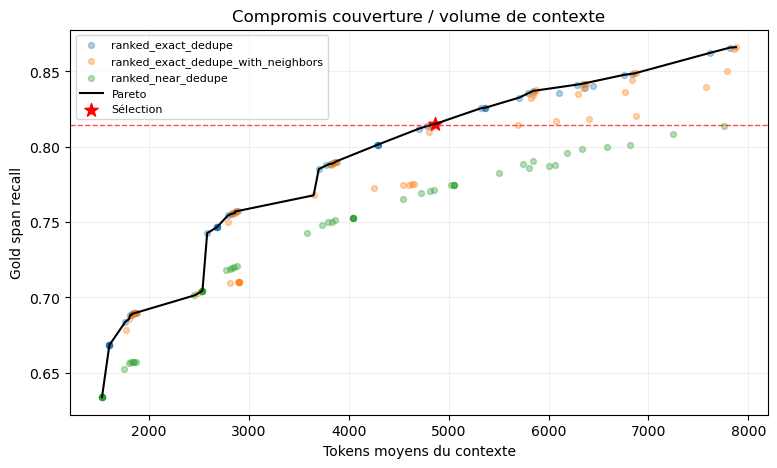

In [8]:
def candidate_ceiling_for_example(example_id: str) -> float:
    example = examples_by_id[example_id]
    candidate_ids = [item["chunk_id"] for item in rankings_by_id[example_id]["candidates"][: config["selection"]["candidate_ceiling_depth"]]]
    covered = set().union(*(set(chunks_by_id[chunk_id]["source_span_ids"]) for chunk_id in candidate_ids))
    gold = set(example["gold"]["span_ids"])
    return len(gold & covered) / len(gold)


candidate_ceiling = float(np.mean([candidate_ceiling_for_example(example_id) for example_id in example_ids]))
target_span_recall = candidate_ceiling * config["selection"]["minimum_candidate_ceiling_retention"]
grid_df["candidate_ceiling_retention"] = grid_df["gold_span_recall"] / candidate_ceiling


def pareto_mask(frame: pd.DataFrame) -> list[bool]:
    result = []
    for index, row in frame.iterrows():
        dominated = ((frame["gold_span_recall"] >= row["gold_span_recall"]) & (frame["mean_context_tokens"] <= row["mean_context_tokens"]) & ((frame["gold_span_recall"] > row["gold_span_recall"]) | (frame["mean_context_tokens"] < row["mean_context_tokens"]))).any()
        result.append(not bool(dominated))
    return result


grid_df["pareto_optimal"] = pareto_mask(grid_df)
selection_config = config["selection"]
eligible_mask = (
    (grid_df["gold_span_recall"] >= target_span_recall)
    & (grid_df["mean_context_tokens"] <= selection_config["maximum_mean_context_tokens"])
    & (grid_df["max_context_tokens"] <= selection_config["maximum_context_tokens"])
    & (grid_df["mean_context_chunks"] <= selection_config["maximum_mean_context_chunks"])
)
eligible_df = grid_df[eligible_mask].copy()
selection_fallback_used = eligible_df.empty
if selection_fallback_used:
    eligible_df = grid_df[
        (grid_df["mean_context_tokens"] <= selection_config["maximum_mean_context_tokens"])
        & (grid_df["max_context_tokens"] <= selection_config["maximum_context_tokens"])
        & (grid_df["mean_context_chunks"] <= selection_config["maximum_mean_context_chunks"])
    ].copy()
    eligible_df = eligible_df.sort_values(["gold_span_recall", "mean_context_tokens"], ascending=[False, True])
else:
    eligible_df["neighbor_penalty"] = eligible_df["mode"].eq("ranked_exact_dedupe_with_neighbors").astype(int)
    eligible_df["near_penalty"] = eligible_df["mode"].eq("ranked_near_dedupe").astype(int)
    eligible_df = eligible_df.sort_values(
        ["mean_context_tokens", "gold_span_recall", "all_spans_covered_rate", "mean_context_chunks", "neighbor_penalty", "near_penalty"],
        ascending=[True, False, False, True, True, True],
    )

selected_row = eligible_df.iloc[0]
selected_policy_id = selected_row["policy_id"]
selected_policy = next(item for item in policies if item["policy_id"] == selected_policy_id)

print(f"Candidate ceiling@{selection_config['candidate_ceiling_depth']} : {candidate_ceiling:.4f}")
print(f"Cible ({selection_config['minimum_candidate_ceiling_retention']:.0%} du plafond) : {target_span_recall:.4f}")
print(f"Politiques admissibles : {int(eligible_mask.sum())}")
print(f"Fallback utilisé : {selection_fallback_used}")
print(f"Politique sélectionnée : {selected_policy_id}")
display(pd.DataFrame([selected_row]).round(4))

pareto_df = grid_df[grid_df["pareto_optimal"]].sort_values("mean_context_tokens")
fig, ax = plt.subplots(figsize=(9, 5))
for mode, part in grid_df.groupby("mode"):
    ax.scatter(part["mean_context_tokens"], part["gold_span_recall"], s=18, alpha=0.35, label=mode)
ax.plot(pareto_df["mean_context_tokens"], pareto_df["gold_span_recall"], color="black", linewidth=1.5, label="Pareto")
ax.scatter([selected_row["mean_context_tokens"]], [selected_row["gold_span_recall"]], color="red", s=100, marker="*", label="Sélection")
ax.axhline(target_span_recall, color="red", linestyle="--", linewidth=1, alpha=0.7)
ax.set_xlabel("Tokens moyens du contexte")
ax.set_ylabel("Gold span recall")
ax.set_title("Compromis couverture / volume de contexte")
ax.grid(alpha=0.2)
ax.legend(fontsize=8)
plt.show()

## 7. Reconstruction de la politique sélectionnée et analyse par slices

Les contextes sont reconstruits une dernière fois. L'artefact destiné à la génération ne contient aucune réponse cible ni aucun span gold. Les métriques d'évaluation sont persistées dans un fichier distinct.

In [9]:
selected_contexts: dict[str, dict[str, Any]] = {}
selected_evaluations = []
for example_id in example_ids:
    built = build_context(rankings_by_id[example_id]["candidates"], selected_policy)
    selected_contexts[example_id] = built
    metrics = evaluate_built_context(examples_by_id[example_id], built)
    selected_evaluations.append({"example_id": example_id, **metrics})

selected_eval_df = pd.DataFrame(selected_evaluations)
assert math.isclose(float(selected_eval_df["gold_span_recall"].mean()), float(selected_row["gold_span_recall"]), abs_tol=1e-12)
selected_exact_overall = {
    "gold_span_recall": float(selected_eval_df["gold_span_recall"].mean()),
    "any_span_covered_rate": float(selected_eval_df["any_span_covered"].mean()),
    "all_spans_covered_rate": float(selected_eval_df["all_spans_covered"].mean()),
    "relevant_chunk_precision": float(selected_eval_df["relevant_chunk_precision"].mean()),
    "mean_context_tokens": float(selected_eval_df["context_tokens"].mean()),
    "p95_context_tokens": float(selected_eval_df["context_tokens"].quantile(0.95)),
    "max_context_tokens": int(selected_eval_df["context_tokens"].max()),
    "mean_context_chunks": float(selected_eval_df["context_chunks"].mean()),
    "p95_context_chunks": float(selected_eval_df["context_chunks"].quantile(0.95)),
}


def slice_name_flags(example_id: str) -> dict[str, bool]:
    example = examples_by_id[example_id]
    rewrite = rewrites_by_id[example_id]
    return {
        "all_primary": True,
        "rewrite_gated": bool(rewrite["gated"]),
        "rewrite_not_gated": not bool(rewrite["gated"]),
        "short_queries": bool(example["query"]["is_short"]),
        "non_short_queries": not bool(example["query"]["is_short"]),
        "overlap_free": bool(example["diagnostics"]["exact_text_overlap_free"]),
    }


slice_rows = []
metric_by_id = {item["example_id"]: item for item in selected_evaluations}
for slice_name in config["evaluation"]["report_slices"]:
    ids = [example_id for example_id in example_ids if slice_name_flags(example_id)[slice_name]]
    part = pd.DataFrame([metric_by_id[example_id] for example_id in ids])
    slice_rows.append({
        "slice": slice_name,
        "queries": len(part),
        "gold_span_recall": float(part["gold_span_recall"].mean()),
        "any_span_covered_rate": float(part["any_span_covered"].mean()),
        "all_spans_covered_rate": float(part["all_spans_covered"].mean()),
        "relevant_chunk_precision": float(part["relevant_chunk_precision"].mean()),
        "mean_context_tokens": float(part["context_tokens"].mean()),
        "p95_context_tokens": float(part["context_tokens"].quantile(0.95)),
        "mean_context_chunks": float(part["context_chunks"].mean()),
        "same_domain_chunk_rate": float(part["same_domain_chunk_rate"].mean()),
    })

slice_df = pd.DataFrame(slice_rows)
display(slice_df.round(4))

sample_ids = sorted(example_ids, key=lambda value: stable_hash({"seed": config["evaluation"]["random_seed"], "example_id": value}))[: config["evaluation"]["sample_contexts"]]
sample_contexts = []
for example_id in sample_ids:
    example = examples_by_id[example_id]
    built = selected_contexts[example_id]
    source_ids = [item["chunk_id"] for item in built["sources"]]
    sample_contexts.append({
        "example_id": example_id,
        "domain": example["domain"],
        "query": example["query"]["text"],
        "policy_id": selected_policy_id,
        "context_tokens": built["context_tokens"],
        "sources": built["sources"],
        "rendered_context": render_context(source_ids),
        "evaluation": metric_by_id[example_id],
    })

display(pd.DataFrame([{
    "example_id": item["example_id"],
    "domain": item["domain"],
    "query": item["query"],
    "tokens": item["context_tokens"],
    "chunks": len(item["sources"]),
    "gold_span_recall": item["evaluation"]["gold_span_recall"],
} for item in sample_contexts]))

,slice,queries,gold_span_recall,any_span_covered_rate,all_spans_covered_rate,relevant_chunk_precision,mean_context_tokens,p95_context_tokens,mean_context_chunks,same_domain_chunk_rate
0,all_primary,4427,0.8150,0.8150,0.8150,0.0929,4852.1730,4985.0,9.1064,0.9040
1,rewrite_gated,2480,0.8464,0.8464,0.8464,0.0977,4853.3774,4985.0,9.0810,0.9506
2,rewrite_not_gated,1947,0.7750,0.7750,0.7750,0.0867,4850.6389,4986.0,9.1387,0.8446
3,short_queries,795,0.8730,0.8730,0.8730,0.1019,4863.4830,4986.0,9.0981,0.9298
4,non_short_queries,3632,0.8023,0.8023,0.8023,0.0909,4849.6974,4985.0,9.1082,0.8983
5,overlap_free,3850,0.8088,0.8088,0.8088,0.0916,4851.2431,4985.0,9.1062,0.9028


,example_id,domain,query,tokens,chunks,gold_span_recall
0,eval_9319fd806331769eafdc3b23,va,ok I understand. and you might know if I am eligible for Veterans Mortgage Life Insurance?,4943,9,1.0
1,eval_4bb8f84ff698b24e33449bec,va,and what law protects my health care coverage?,4918,9,0.0
2,eval_e020c78bcf9bf55eb291edeb,dmv,How do I surrender New York State plates to the DMV?,4977,9,1.0
3,eval_9a6ae1ee3d7f80d3d3fc927a,va,"As a family member caring for a disabled veteran, am I eligible for any benefits?",4987,8,0.0
4,eval_4e3ec0af5de71c608423f526,va,"I have another question for you regarding benefits or service access. What if I have concerns about these matters? So, would you help me?",4982,9,0.0
5,eval_86538561c58ac35818690704,dmv,What do I need to know about renewing my ID card?,4869,9,1.0
6,eval_ada3731d4a70397f095f140f,va,Hello. I'm trying to get information about Camp Lejeune's water problems.,4877,9,1.0
7,eval_35d9cad4c4a5abe5f4c99863,ssa,I want info about what happens to my benefits if I want to keep working,4690,9,0.0
8,eval_97d567190a18e5a59e3fa13c,va,What if I am re-enrolled in VA health care?,4755,8,0.0
9,eval_2effcf9da30e9e0b739cca72,studentaid,Is there anywhere on the website that I can send feedback to try to streamline the process or make it more user friendly?,4812,10,1.0


## 8. Quality gates, persistance et vérification

Le contexte de production est référentiel : il contient les identifiants et métadonnées nécessaires pour reconstruire le texte depuis le chunk store, mais aucune vérité terrain. Un échantillon rendu est conservé pour inspection humaine.

In [10]:
quality_errors = []
quality_warnings = []
quality_targets = config["quality_targets"]
selected_span_recall = float(selected_eval_df["gold_span_recall"].mean())
selected_ceiling_retention = selected_span_recall / candidate_ceiling
budget_violation_count = sum(selected_contexts[example_id]["context_tokens"] > selected_policy["token_budget"] for example_id in example_ids)
duplicate_chunk_id_count = sum(len([item["chunk_id"] for item in selected_contexts[example_id]["sources"]]) != len(set(item["chunk_id"] for item in selected_contexts[example_id]["sources"])) for example_id in example_ids)
invalid_citation_count = sum([item["citation_id"] for item in selected_contexts[example_id]["sources"]] != [citation_id(position) for position in range(1, len(selected_contexts[example_id]["sources"]) + 1)] for example_id in example_ids)

if selected_span_recall < quality_targets["minimum_selected_gold_span_recall"]:
    quality_errors.append(f"Gold span recall insuffisant : {selected_span_recall:.4f}")
if selected_ceiling_retention < quality_targets["minimum_selected_ceiling_retention"]:
    quality_errors.append(f"Rétention du plafond insuffisante : {selected_ceiling_retention:.4f}")
if budget_violation_count > quality_targets["maximum_selected_budget_violation_count"]:
    quality_errors.append(f"Violations du budget : {budget_violation_count}")
if duplicate_chunk_id_count > quality_targets["maximum_duplicate_chunk_id_count"]:
    quality_errors.append(f"Contextes avec chunk_id dupliqué : {duplicate_chunk_id_count}")
if invalid_citation_count > quality_targets["maximum_invalid_citation_count"]:
    quality_errors.append(f"Contextes avec citations invalides : {invalid_citation_count}")
if selection_fallback_used:
    quality_warnings.append("Aucune politique n'a atteint la cible multi-objectifs; fallback de sélection utilisé")
if selected_row["mean_context_tokens"] > 6000:
    quality_warnings.append("Contexte moyen supérieur à 6 000 tokens; le coût et l'effet du bruit devront être validés end-to-end")

quality_status = "passed" if not quality_errors else "failed"
print(f"Quality : {quality_status}")
print(f"Errors : {quality_errors}")
print(f"Warnings : {quality_warnings}")
assert not quality_errors, quality_errors


def context_records() -> Iterator[dict[str, Any]]:
    for example_id in example_ids:
        example = examples_by_id[example_id]
        built = selected_contexts[example_id]
        yield {
            "schema_version": "1.0.0",
            "experiment_id": experiment_id,
            "example_id": example_id,
            "split": "validation",
            "domain": example["domain"],
            "user_query": example["query"]["text"],
            "history": example["history"],
            "policy_id": selected_policy_id,
            "token_budget": built["token_budget"],
            "context_tokens": built["context_tokens"],
            "conservative_context_tokens": built["conservative_context_tokens"],
            "rendering_version": rendering["version"],
            "rendered_context_sha256": built["rendered_context_sha256"],
            "sources": [{key: value for key, value in source.items() if key != "content_hash"} for source in built["sources"]],
        }


def evaluation_records() -> Iterator[dict[str, Any]]:
    for item in selected_evaluations:
        yield {"schema_version": "1.0.0", "experiment_id": experiment_id, **item}


context_path = OUTPUT_ROOT / "contexts" / "validation_selected.jsonl"
evaluation_path = OUTPUT_ROOT / "evaluation" / "validation_context_metrics.jsonl"
context_count = write_jsonl_atomic(context_path, context_records())
evaluation_count = write_jsonl_atomic(evaluation_path, evaluation_records())

grid_path = REPORT_ROOT / "policy_grid.json"
pareto_path = REPORT_ROOT / "pareto_frontier.json"
slice_path = REPORT_ROOT / "slice_metrics.json"
sample_path = REPORT_ROOT / "sample_contexts.json"
write_json_atomic(grid_path, dataframe_records(grid_df.sort_values(["gold_span_recall", "mean_context_tokens"], ascending=[False, True])))
write_json_atomic(pareto_path, dataframe_records(pareto_df))
write_json_atomic(slice_path, dataframe_records(slice_df))
write_json_atomic(sample_path, sample_contexts)

report_artifacts = {
    "policy_grid.json": artifact_metadata(grid_path, len(grid_df)),
    "pareto_frontier.json": artifact_metadata(pareto_path, len(pareto_df)),
    "slice_metrics.json": artifact_metadata(slice_path, len(slice_df)),
    "sample_contexts.json": artifact_metadata(sample_path, len(sample_contexts)),
}

manifest = {
    "schema_version": "1.0.0",
    "pipeline_stage": "context_builder_evaluation",
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "experiment_id": experiment_id,
    "experiment_fingerprint": experiment_fingerprint,
    "implementation_version": config["implementation_version"],
    "configuration_path": str(CONFIG_PATH.relative_to(PROJECT_ROOT)),
    "configuration_hash": config_hash,
    "inputs": {
        "benchmark_id": config["benchmark_id"],
        "validation_sha256": validation_expected["sha256"],
        "chunking_experiment_id": config["chunking_experiment_id"],
        "chunk_strategy": config["chunking_strategy"],
        "chunks_sha256": file_sha256(chunk_path),
        "reranking_experiment_id": config["reranking_experiment_id"],
        "reranking_report_sha256": file_sha256(reranker_report_path),
        "selected_rankings_sha256": ranking_meta["sha256"],
        "query_rewriting_experiment_id": query_experiment_id,
        "rewrites_sha256": file_sha256(rewrite_path),
    },
    "evaluation": {
        "split": "validation",
        "cohort": config["cohort"],
        "queries": len(example_ids),
        "policies": len(policies),
        "candidate_ceiling_depth": selection_config["candidate_ceiling_depth"],
        "candidate_ceiling_gold_span_recall": candidate_ceiling,
        "target_gold_span_recall": target_span_recall,
        "grid_seconds": grid_seconds,
    },
    "selected_policy": selected_policy,
    "selected_metrics": {key: value for key, value in dataframe_records(pd.DataFrame([selected_row]))[0].items() if key not in {"neighbor_penalty", "near_penalty"}},
    "selected_exact_metrics": selected_exact_overall,
    "selection_fallback_used": selection_fallback_used,
    "quality": {
        "status": quality_status,
        "errors": quality_errors,
        "warnings": quality_warnings,
        "test_split_loaded": False,
        "budget_violation_count": budget_violation_count,
        "duplicate_chunk_id_count": duplicate_chunk_id_count,
        "invalid_citation_count": invalid_citation_count,
        "selected_ceiling_retention": selected_ceiling_retention,
        "builder_gold_access": False,
    },
    "artifacts": {
        "selected_contexts": artifact_metadata(context_path, context_count),
        "selected_context_evaluation": artifact_metadata(evaluation_path, evaluation_count),
        "reports": report_artifacts,
    },
    "decision": "Context policy selected on validation for the generation experiment. Selection remains provisional until end-to-end answer and citation evaluation; test remains locked.",
}

manifest_path = OUTPUT_ROOT / "manifest.json"
report_path = REPORT_ROOT / "context_builder_report.json"
write_json_atomic(manifest_path, manifest)
write_json_atomic(report_path, {**manifest, "policy_grid_top_20": dataframe_records(grid_df.sort_values(["gold_span_recall", "mean_context_tokens"], ascending=[False, True]).head(20)), "slice_metrics": dataframe_records(slice_df)})

persisted = load_json(report_path)
assert persisted["quality"]["status"] == "passed"
assert persisted["quality"]["test_split_loaded"] is False
assert sum(1 for _ in iter_jsonl(context_path)) == len(example_ids)
assert sum(1 for _ in iter_jsonl(evaluation_path)) == len(example_ids)
assert file_sha256(context_path) == persisted["artifacts"]["selected_contexts"]["sha256"]
assert file_sha256(evaluation_path) == persisted["artifacts"]["selected_context_evaluation"]["sha256"]
for filename, metadata in report_artifacts.items():
    assert file_sha256(REPORT_ROOT / filename) == metadata["sha256"]

print(f"✅ Rapport : {report_path}")
print(f"✅ Politique : {selected_policy_id}")
print(f"✅ Gold span recall={selected_span_recall:.4f}; plafond retenu={selected_ceiling_retention:.2%}")
print("✅ Test non chargé; artefacts cohérents; builder sans accès au gold")

Quality : passed
Errors : []
Warnings : []
✅ Rapport : C:\Users\dhiar\OneDrive\Bureau\Project\RAG Assistant\reports\generated\multidoc2dial_v1\context_builder_experiments\context_builder_v1_860d7c5b2f\context_builder_report.json
✅ Politique : ranked_exact_dedupe__k20__b5000
✅ Gold span recall=0.8150; plafond retenu=86.03%
✅ Test non chargé; artefacts cohérents; builder sans accès au gold


## 9. Comment interpréter la décision

La politique choisie optimise la **présence des preuves sous contrainte de tokens**, pas encore la qualité de la réponse. Un contexte plus long peut augmenter la couverture tout en ajoutant du bruit. La sélection sera donc remise en concurrence lors de l'évaluation end-to-end : génération, faithfulness, exactitude des citations, latence et coût. Le test reste verrouillé jusqu'au gel complet du pipeline.